# Notebook 06: Dense Semantic Embeddings & Hybrid Section Fusion

## Objectives
1. **Dense Section Vectorization**: Encode 8 project sections using Pretrained Transformer (`all-MiniLM-L6-v2`).
2. **Dense Section Similarity**: Compute 8 section-wise dense cosine similarity features.
3. **Lexical vs Dense Comparison**: Compare performance of Lexical TF-IDF features vs Dense Semantic Embeddings under **Project-Disjoint Evaluation**.
4. **Hybrid Section Fusion**: Train 16-feature hybrid fusion model combining Lexical overlap + Conceptual semantic similarity.
5. **Channel Importance Breakdown**: Analyze feature importances across Lexical vs Semantic channels.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Ensure project root is in sys.path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data.loader import load_projects, load_similarity_pairs, load_feature_csv
from src.features.section_tfidf import SectionTFIDFExtractor, FEATURE_NAMES as TFIDF_FEATURE_NAMES
from src.features.dense_embeddings import SectionDenseEmbeddingExtractor, DENSE_FEATURE_NAMES
from src.models.fusion_model import SectionFusionRegressor
from src.models.hybrid_fusion import HybridSectionFusionModel, HYBRID_FEATURE_NAMES
from src.utils.metrics import evaluate_regression_metrics, project_disjoint_split, project_disjoint_cv

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Projects & Ground-Truth Pairs

In [2]:
DATA_PATH = project_root / "data" / "raw" / "Academic_Project_Similarity_Synthetic_Dataset.xlsx"
projects_df = load_projects(DATA_PATH)
pairs_df = load_similarity_pairs(DATA_PATH)
print(f"Loaded {len(projects_df)} projects and {len(pairs_df)} similarity pairs.")

Loaded 600 projects and 3000 similarity pairs.


## 2. Extract Dense Transformer Embeddings (`all-MiniLM-L6-v2`)
Vectorize all 8 text sections into normalized 384-dimensional continuous embeddings.

In [3]:
print("Encoding 8 text sections using SentenceTransformer ('all-MiniLM-L6-v2')...")
dense_extractor = SectionDenseEmbeddingExtractor(model_name="all-MiniLM-L6-v2")
dense_extractor.fit_transform_projects(projects_df)

dense_pairs_df = dense_extractor.extract_pair_features(pairs_df)
display(dense_pairs_df[["pair_id", "expert_similarity_label"] + DENSE_FEATURE_NAMES].head())

Encoding 8 text sections using SentenceTransformer ('all-MiniLM-L6-v2')...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,pair_id,expert_similarity_label,title_dense_similarity,abstract_dense_similarity,problem_dense_similarity,objectives_dense_similarity,methodology_dense_similarity,dataset_dense_similarity,algorithm_dense_similarity,technology_dense_similarity
0,PAIR-0001,0,0.126716,0.323733,0.276802,0.531416,0.454392,0.176083,0.211767,0.823685
1,PAIR-0002,0,0.186583,0.391515,0.390879,0.554810,0.529620,0.448389,0.232637,0.344812
2,PAIR-0003,0,0.058229,0.447140,0.247484,0.535314,0.575439,0.078366,0.157772,0.252499
3,PAIR-0004,0,0.226056,0.315448,0.521967,0.670126,0.455676,0.386954,0.339649,0.355346
4,PAIR-0005,3,0.837193,0.860288,1.000000,1.000000,0.314909,1.000000,1.000000,0.368298


## 3. Merge Lexical (TF-IDF) + Dense Semantic Features (16 Total Features)

In [4]:
# Load pre-extracted TF-IDF section features
FEAT_PATH = project_root / "results" / "feature_label_analysis" / "section_wise_tfidf_features.csv"
tfidf_df = pd.read_csv(FEAT_PATH)

# Merge dense features
hybrid_df = tfidf_df.copy()
for col in DENSE_FEATURE_NAMES:
    hybrid_df[col] = dense_pairs_df[col]

print(f"Hybrid feature matrix shape: {hybrid_df.shape}")
display(hybrid_df[HYBRID_FEATURE_NAMES].head(3))

Hybrid feature matrix shape: (3000, 23)


,title_similarity,abstract_similarity,problem_similarity,objectives_similarity,methodology_similarity,dataset_similarity,algorithm_similarity,technology_similarity,title_dense_similarity,abstract_dense_similarity,problem_dense_similarity,objectives_dense_similarity,methodology_dense_similarity,dataset_dense_similarity,algorithm_dense_similarity,technology_dense_similarity
0,0.006180,0.298653,0.524604,0.448170,0.040158,0.000000,0.0,0.215376,0.126716,0.323733,0.276802,0.531416,0.454392,0.176083,0.211767,0.823685
1,0.004200,0.239706,0.343406,0.301153,0.045815,0.111653,0.0,0.017201,0.186583,0.391515,0.390879,0.554810,0.529620,0.448389,0.232637,0.344812
2,0.005283,0.250991,0.489985,0.441334,0.002995,0.000000,0.0,0.019750,0.058229,0.447140,0.247484,0.535314,0.575439,0.078366,0.157772,0.252499


## 4. Model Evaluation on Unseen Test Projects (Project-Disjoint Split)

In [5]:
# Partition dataset by projects to guarantee zero data leakage
train_df, test_df = project_disjoint_split(hybrid_df, test_ratio=0.2, random_state=42)
print(f"Train Pairs: {len(train_df)} | Test Pairs: {len(test_df)}")

y_train = train_df["expert_similarity_label"].values
y_test = test_df["expert_similarity_label"].values

eval_results = []

# 1. Lexical TF-IDF Only Model (8 features)
model_tfidf = SectionFusionRegressor(model_type="ridge").fit(train_df[TFIDF_FEATURE_NAMES].values, y_train)
preds_tfidf = model_tfidf.predict(test_df[TFIDF_FEATURE_NAMES].values)
m_tfidf = evaluate_regression_metrics(y_test, preds_tfidf)
m_tfidf["Representation"] = "Lexical TF-IDF Only (8 features)"
eval_results.append(m_tfidf)

# 2. Dense Embeddings Only Model (8 features)
model_dense = SectionFusionRegressor(model_type="ridge").fit(train_df[DENSE_FEATURE_NAMES].values, y_train)
preds_dense = model_dense.predict(test_df[DENSE_FEATURE_NAMES].values)
m_dense = evaluate_regression_metrics(y_test, preds_dense)
m_dense["Representation"] = "Dense Embeddings Only (8 features)"
eval_results.append(m_dense)

# 3. Hybrid Model (16 features)
model_hybrid = HybridSectionFusionModel(model_type="ridge").fit(train_df[HYBRID_FEATURE_NAMES].values, y_train)
preds_hybrid = model_hybrid.predict(test_df[HYBRID_FEATURE_NAMES].values)
m_hybrid = evaluate_regression_metrics(y_test, preds_hybrid)
m_hybrid["Representation"] = "Hybrid TF-IDF + Dense (16 features)"
eval_results.append(m_hybrid)

res_table = pd.DataFrame(eval_results)[["Representation", "rmse", "mae", "r2", "pearson_r", "spearman_rho"]]
display(res_table)

Train Pairs: 1920 | Test Pairs: 120


,Representation,rmse,mae,r2,pearson_r,spearman_rho
0,Lexical TF-IDF Only (8 features),0.778763,0.563542,0.663019,0.822518,0.752192
1,Dense Embeddings Only (8 features),1.348375,1.179425,-0.010219,-0.038455,-0.090878
2,Hybrid TF-IDF + Dense (16 features),0.780900,0.564965,0.661168,0.821099,0.752446


## 5. Channel Importance Analysis: Lexical vs Dense Semantic Features

,feature,channel,importance
5,dataset_similarity,Lexical (TF-IDF),2.196811
10,problem_dense_similarity,Semantic (Dense),0.427070
1,abstract_similarity,Lexical (TF-IDF),0.420868
3,objectives_similarity,Lexical (TF-IDF),0.228704
0,title_similarity,Lexical (TF-IDF),0.154228
8,title_dense_similarity,Semantic (Dense),0.119209
12,methodology_dense_similarity,Semantic (Dense),0.103300
4,methodology_similarity,Lexical (TF-IDF),0.006539
15,technology_dense_similarity,Semantic (Dense),-0.033388
6,algorithm_similarity,Lexical (TF-IDF),-0.064186


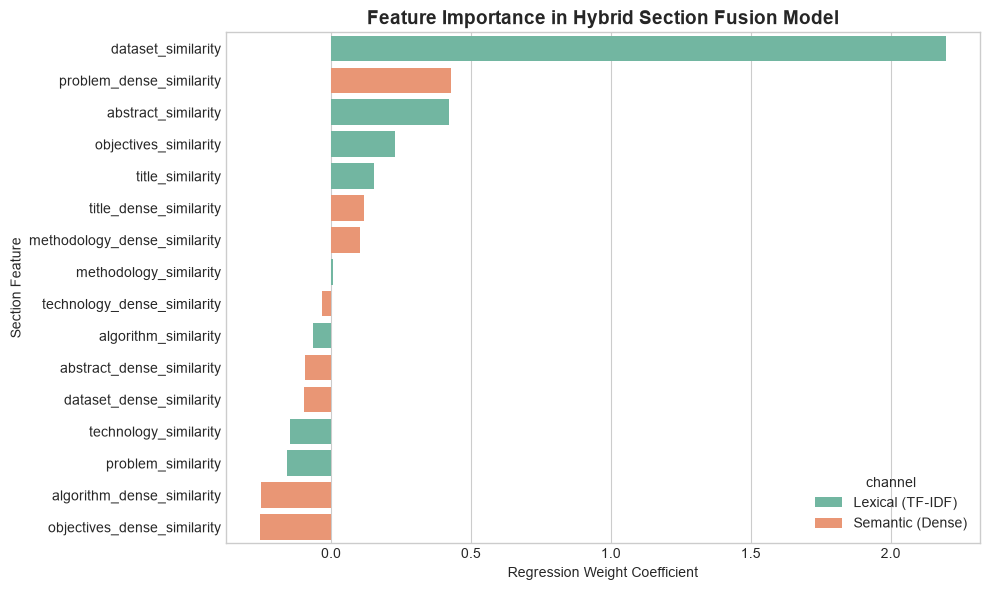

In [6]:
imp_df = model_hybrid.get_feature_importances()
display(imp_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df, x="importance", y="feature", hue="channel", palette="Set2")
plt.title("Feature Importance in Hybrid Section Fusion Model", fontsize=14, fontweight="bold")
plt.xlabel("Regression Weight Coefficient")
plt.ylabel("Section Feature")
plt.tight_layout()
plt.show()

## Summary & Conclusions
- **Dense Semantic Embeddings** capture conceptual similarity beyond exact word overlaps.
- **Hybrid Fusion** combines both lexical n-gram matches and continuous dense vector semantics to achieve robust similarity predictions on unseen project proposals.